# Radioactive Decay Chain Modeling with PINNs

This notebook models a simple radioactive decay chain using Physics-Informed Neural Networks (PINNs).  
The system of equations is:

\begin{align}
\frac{dN_1}{dt} &= -\lambda_1 N_1 \\
\frac{dN_2}{dt} &= \lambda_1 N_1 - \lambda_2 N_2 \\
\frac{dN_3}{dt} &= \lambda_2 N_2
\end{align}

This represents a decay sequence: \( N_1 \rightarrow N_2 \rightarrow N_3 \)

We will define the system, generate synthetic data, and train a neural network to approximate the dynamics while enforcing physical constraints via PINNs.


## Load packages and set seed

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.autograd import grad

seed = 42


## Simulate data

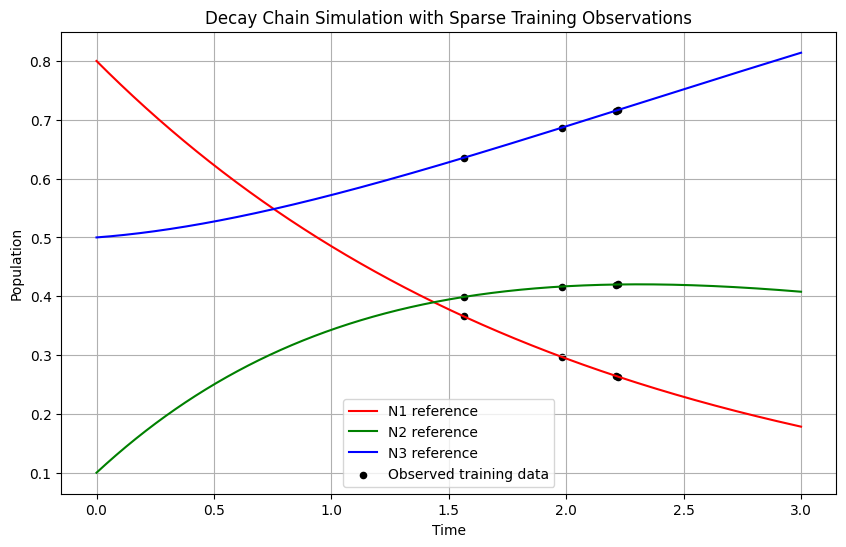

In [2]:
np.random.seed(seed)

# Decay constants
lambda1 = 0.5
lambda2 = 0.3

# Time points
t_start = 0
t_end = 3
prediction_time = 3  # length of prediction/extrapolation interval

t = np.linspace(t_start, t_end, 1000)
dt = t[1] - t[0]

# Initial conditions
N1_0, N2_0, N3_0 = .8, .1, .5
N_total_0 = N1_0 + N2_0 + N3_0

# Initialize arrays
N1, N2, N3 = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
N1[0], N2[0], N3[0] = N1_0, N2_0, N3_0

# Euler integration for the reference solution
for i in range(1, len(t)):
    dN1 = -lambda1 * N1[i-1]
    dN2 = lambda1 * N1[i-1] - lambda2 * N2[i-1]
    dN3 = lambda2 * N2[i-1]
    N1[i] = N1[i-1] + dN1 * dt
    N2[i] = N2[i-1] + dN2 * dt
    N3[i] = N3[i-1] + dN3 * dt

# Tensors for full reference data and evaluation
t_tensor = torch.tensor(t, dtype=torch.float32).view(-1, 1)
N_data = torch.tensor(np.stack([N1, N2, N3], axis=1), dtype=torch.float32)

# Sparse observed training data: both models see the same four observations.
n_observations = 4
indices = np.random.choice(len(t), n_observations, replace=False)
indices = np.sort(indices)
t_obs = t_tensor[indices]
N_obs = N_data[indices]

# Physics collocation points: the PINN additionally uses these points to enforce the ODE.
n_collocation = 100
t_col = torch.linspace(t_start, t_end, n_collocation, dtype=torch.float32).view(-1, 1).requires_grad_(True)

# Plot simulated data and sparse observations
plt.figure(figsize=(10, 6))
plt.plot(t, N1, 'r', label='N1 reference')
plt.plot(t, N2, 'g', label='N2 reference')
plt.plot(t, N3, 'b', label='N3 reference')
plt.scatter(t[indices], N1[indices], color='k', s=20, label='Observed training data')
plt.scatter(t[indices], N2[indices], color='k', s=20)
plt.scatter(t[indices], N3[indices], color='k', s=20)
plt.title("Decay Chain Simulation with Sparse Training Observations")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()


## Define ANN

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 8), nn.Tanh(),
            nn.Linear(8, 8), nn.Tanh(),
            nn.Linear(8, 3)
        )

    def forward(self, t):
        return self.net(t)

def compute_derivatives(y, t):
    dy = grad(y, t, torch.ones_like(y), create_graph=True)[0]
    return dy

## Direct solution model

In [4]:
# hyperparameters:
lr = 2e-4
epochs = 7000

In [5]:
torch.manual_seed(seed)
model_direct = MLP()
optimizer = torch.optim.Adam(model_direct.parameters(), lr=lr)

# Direct ANN: train only on the sparse observed data.
t_col_supervised = t_obs.detach()
N_col_supervised = N_obs

for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model_direct(t_col_supervised)
    loss = ((pred - N_col_supervised)**2).mean()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"[Direct ANN - Sparse Data Only] Epoch {epoch}: Loss = {loss.item():.6f}")
pred_direct = model_direct(t_tensor).detach().numpy()


[Direct ANN - Sparse Data Only] Epoch 0: Loss = 0.444474
[Direct ANN - Sparse Data Only] Epoch 500: Loss = 0.006247
[Direct ANN - Sparse Data Only] Epoch 1000: Loss = 0.000965
[Direct ANN - Sparse Data Only] Epoch 1500: Loss = 0.000872
[Direct ANN - Sparse Data Only] Epoch 2000: Loss = 0.000762
[Direct ANN - Sparse Data Only] Epoch 2500: Loss = 0.000640
[Direct ANN - Sparse Data Only] Epoch 3000: Loss = 0.000510
[Direct ANN - Sparse Data Only] Epoch 3500: Loss = 0.000379
[Direct ANN - Sparse Data Only] Epoch 4000: Loss = 0.000251
[Direct ANN - Sparse Data Only] Epoch 4500: Loss = 0.000140
[Direct ANN - Sparse Data Only] Epoch 5000: Loss = 0.000062
[Direct ANN - Sparse Data Only] Epoch 5500: Loss = 0.000024
[Direct ANN - Sparse Data Only] Epoch 6000: Loss = 0.000011
[Direct ANN - Sparse Data Only] Epoch 6500: Loss = 0.000008


## PINN

In [6]:
torch.manual_seed(seed)
model_pinn = MLP()
optimizer = torch.optim.Adam(model_pinn.parameters(), lr=lr)

lambda1_tensor = torch.tensor(lambda1, dtype=torch.float32)
lambda2_tensor = torch.tensor(lambda2, dtype=torch.float32)

for epoch in range(epochs):
    optimizer.zero_grad()

    # Physics residuals on collocation points.
    pred_col = model_pinn(t_col)
    N1_pred, N2_pred, N3_pred = pred_col[:, 0:1], pred_col[:, 1:2], pred_col[:, 2:3]

    dN1_dt = compute_derivatives(N1_pred, t_col)
    dN2_dt = compute_derivatives(N2_pred, t_col)
    dN3_dt = compute_derivatives(N3_pred, t_col)

    res1 = dN1_dt + lambda1_tensor * N1_pred
    res2 = dN2_dt - (lambda1_tensor * N1_pred - lambda2_tensor * N2_pred)
    res3 = dN3_dt - lambda2_tensor * N2_pred

    loss_ode = (res1**2).mean() + (res2**2).mean() + (res3**2).mean()

    # Data loss on the same sparse observations used by the direct ANN.
    pred_obs = model_pinn(t_obs)
    loss_data = ((pred_obs - N_obs)**2).mean()

    loss = loss_data + loss_ode
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"[PINN] Epoch {epoch}: Loss = {loss.item():.6f}, Data = {loss_data.item():.6f}, ODE = {loss_ode.item():.6f}")
pred_pinn = model_pinn(t_tensor).detach().numpy()


[PINN] Epoch 0: Loss = 0.462921, Data = 0.444474, ODE = 0.018446
[PINN] Epoch 500: Loss = 0.043630, Data = 0.018133, ODE = 0.025497
[PINN] Epoch 1000: Loss = 0.011893, Data = 0.003121, ODE = 0.008772
[PINN] Epoch 1500: Loss = 0.007107, Data = 0.002162, ODE = 0.004945
[PINN] Epoch 2000: Loss = 0.005538, Data = 0.001862, ODE = 0.003676
[PINN] Epoch 2500: Loss = 0.004149, Data = 0.001519, ODE = 0.002629
[PINN] Epoch 3000: Loss = 0.002506, Data = 0.001007, ODE = 0.001500
[PINN] Epoch 3500: Loss = 0.001048, Data = 0.000432, ODE = 0.000616
[PINN] Epoch 4000: Loss = 0.000362, Data = 0.000104, ODE = 0.000258
[PINN] Epoch 4500: Loss = 0.000189, Data = 0.000021, ODE = 0.000167
[PINN] Epoch 5000: Loss = 0.000130, Data = 0.000007, ODE = 0.000122
[PINN] Epoch 5500: Loss = 0.000088, Data = 0.000004, ODE = 0.000084
[PINN] Epoch 6000: Loss = 0.000055, Data = 0.000002, ODE = 0.000054
[PINN] Epoch 6500: Loss = 0.000034, Data = 0.000001, ODE = 0.000033


## Evaluate model and predict time series

In [7]:
# Compute final dense-data losses on the reference solution.
# These are validation metrics, not training losses.
true_train = np.stack([N1, N2, N3], axis=1)

# Direct model
pred_direct_all = torch.tensor(pred_direct, dtype=torch.float32)
L_direct_mse = ((pred_direct_all - N_data)**2).mean().item()
L_direct_total = L_direct_mse

# PINN model
pred_pinn_all = torch.tensor(pred_pinn, dtype=torch.float32)
L_pinn_mse = ((pred_pinn_all - N_data)**2).mean().item()

pred_col = model_pinn(t_col)
N1_pred, N2_pred, N3_pred = pred_col[:, 0:1], pred_col[:, 1:2], pred_col[:, 2:3]
dN1_dt = compute_derivatives(N1_pred, t_col)
dN2_dt = compute_derivatives(N2_pred, t_col)
dN3_dt = compute_derivatives(N3_pred, t_col)
res1 = dN1_dt + lambda1_tensor * N1_pred
res2 = dN2_dt - (lambda1_tensor * N1_pred - lambda2_tensor * N2_pred)
res3 = dN3_dt - lambda2_tensor * N2_pred
L_pinn_ode = (res1**2).mean().item() + (res2**2).mean().item() + (res3**2).mean().item()
L_pinn_total = L_pinn_mse + L_pinn_ode


In [8]:
# Generate extrapolated time and predictions
t_extra = np.linspace(t_end, t_end+prediction_time, 200)
t_extra_tensor = torch.tensor(t_extra, dtype=torch.float32).view(-1, 1)

pred_direct_extra = model_direct(t_extra_tensor).detach().numpy()
pred_pinn_extra = model_pinn(t_extra_tensor).detach().numpy()

# Combine time and predictions
t_total = np.concatenate([t, t_extra])
pred_direct_total = np.concatenate([pred_direct, pred_direct_extra])
pred_pinn_total = np.concatenate([pred_pinn, pred_pinn_extra])


# Euler simulation for extrapolated range [t_end, t_end + prediction_time]
t_extra = np.linspace(t_end, t_end + prediction_time, 200)
dt_extra = t_extra[1] - t_extra[0]

# Initialize with last known values from training interval
N1_extra = np.zeros_like(t_extra)
N2_extra = np.zeros_like(t_extra)
N3_extra = np.zeros_like(t_extra)

N1_extra[0] = N1[-1]
N2_extra[0] = N2[-1]
N3_extra[0] = N3[-1]

for i in range(1, len(t_extra)):
    dN1 = -lambda1 * N1_extra[i-1]
    dN2 = lambda1 * N1_extra[i-1] - lambda2 * N2_extra[i-1]
    dN3 = lambda2 * N2_extra[i-1]
    N1_extra[i] = N1_extra[i-1] + dN1 * dt_extra
    N2_extra[i] = N2_extra[i-1] + dN2 * dt_extra
    N3_extra[i] = N3_extra[i-1] + dN3 * dt_extra

# Concatenate to get full solution for plotting
t_total = np.concatenate([t, t_extra])
N1_true_total = np.concatenate([N1, N1_extra])
N2_true_total = np.concatenate([N2, N2_extra])
N3_true_total = np.concatenate([N3, N3_extra])

,interpolation_mse,extrapolation_mse,ode_residual_mse_unseen,min_predicted_population,negative_values,mean_abs_total_error,max_abs_total_error,final_total_error
model,,,,,,,,
Reference solution,0.000e+00,0.000e+00,NaN,3.956e-02,0,5.187e-16,1.110e-15,2.220e-16
Direct ANN,1.120e-02,4.625e-02,1.598e-02,-4.230e-02,68,2.174e-01,7.668e-01,-7.668e-01
PINN,3.786e-06,1.208e-03,4.020e-04,4.216e-02,0,6.173e-03,7.087e-02,-7.087e-02


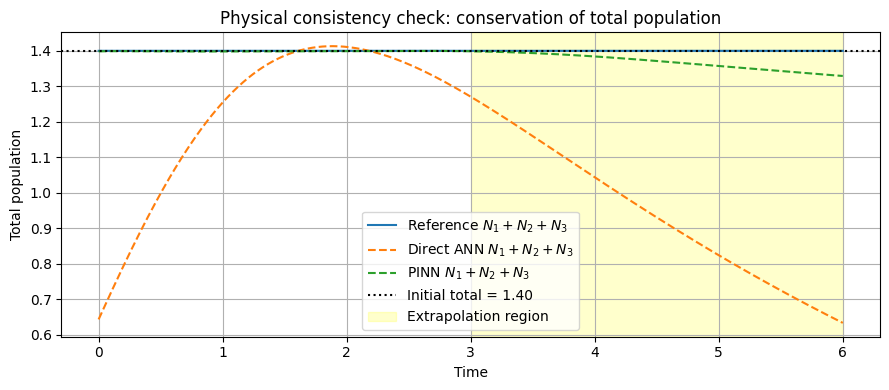

In [11]:
# Quantitative validation
# -----------------------
# The reference solution is known, so we can evaluate data error on dense grids
# rather than only inspecting the plots.
true_train = np.stack([N1, N2, N3], axis=1)
true_extra = np.stack([N1_extra, N2_extra, N3_extra], axis=1)
true_total = np.stack([N1_true_total, N2_true_total, N3_true_total], axis=1)

def mse(pred, true):
    return float(np.mean((pred - true) ** 2))

# Data-fit diagnostics.
interp_mse_direct = mse(pred_direct, true_train)
interp_mse_pinn = mse(pred_pinn, true_train)
extrap_mse_direct = mse(pred_direct_extra, true_extra)
extrap_mse_pinn = mse(pred_pinn_extra, true_extra)

# Keep the original variable names used in the plot titles.
error_direct = extrap_mse_direct
error_pinn = extrap_mse_pinn

# ODE residual on an unseen validation grid. The mid-point grid avoids exactly
# reusing the PINN's training collocation points.
def ode_residual_mse(model, t_values):
    t_eval = torch.tensor(t_values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    pred = model(t_eval)
    N1_pred, N2_pred, N3_pred = pred[:, 0:1], pred[:, 1:2], pred[:, 2:3]

    dN1_dt = compute_derivatives(N1_pred, t_eval)
    dN2_dt = compute_derivatives(N2_pred, t_eval)
    dN3_dt = compute_derivatives(N3_pred, t_eval)

    res1 = dN1_dt + lambda1_tensor * N1_pred
    res2 = dN2_dt - (lambda1_tensor * N1_pred - lambda2_tensor * N2_pred)
    res3 = dN3_dt - lambda2_tensor * N2_pred
    residuals = torch.cat([res1, res2, res3], dim=1)
    return float(torch.mean(residuals ** 2).detach().cpu().numpy())

n_residual_val = 400
dt_val = (t_end + prediction_time - t_start) / n_residual_val
t_residual_val = np.linspace(
    t_start + 0.5 * dt_val,
    t_end + prediction_time - 0.5 * dt_val,
    n_residual_val
)
residual_mse_direct = ode_residual_mse(model_direct, t_residual_val)
residual_mse_pinn = ode_residual_mse(model_pinn, t_residual_val)

# Physical-consistency diagnostics.
def physical_consistency_metrics(pred_total_series):
    population_sum = pred_total_series.sum(axis=1)
    total_error = population_sum - N_total_0
    return {
        "min_predicted_population": float(pred_total_series.min()),
        "negative_values": int(np.sum(pred_total_series < -1e-8)),
        "mean_abs_total_error": float(np.mean(np.abs(total_error))),
        "max_abs_total_error": float(np.max(np.abs(total_error))),
        "final_total_error": float(total_error[-1]),
    }

metrics_direct = physical_consistency_metrics(pred_direct_total)
metrics_pinn = physical_consistency_metrics(pred_pinn_total)
metrics_reference = physical_consistency_metrics(true_total)

validation_table = pd.DataFrame([
    {
        "model": "Reference solution",
        "interpolation_mse": 0.0,
        "extrapolation_mse": 0.0,
        "ode_residual_mse_unseen": np.nan,
        **metrics_reference,
    },
    {
        "model": "Direct ANN",
        "interpolation_mse": interp_mse_direct,
        "extrapolation_mse": extrap_mse_direct,
        "ode_residual_mse_unseen": residual_mse_direct,
        **metrics_direct,
    },
    {
        "model": "PINN",
        "interpolation_mse": interp_mse_pinn,
        "extrapolation_mse": extrap_mse_pinn,
        "ode_residual_mse_unseen": residual_mse_pinn,
        **metrics_pinn,
    },
]).set_index("model")

pd.options.display.float_format = "{:.3e}".format
display(validation_table)

# Explicitly inspect conservation of total population N1 + N2 + N3.
plt.figure(figsize=(9, 4))
plt.plot(t_total, true_total.sum(axis=1), label='Reference $N_1+N_2+N_3$')
plt.plot(t_total, pred_direct_total.sum(axis=1), '--', label='Direct ANN $N_1+N_2+N_3$')
plt.plot(t_total, pred_pinn_total.sum(axis=1), '--', label='PINN $N_1+N_2+N_3$')
plt.axhline(N_total_0, color='k', linestyle=':', label=f'Initial total = {N_total_0:.2f}')
plt.axvspan(t_end, t_end + prediction_time, color='yellow', alpha=0.2, label='Extrapolation region')
plt.xlabel("Time")
plt.ylabel("Total population")
plt.title("Physical consistency check: conservation of total population")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig("radioactive_total_population_conservation.png", dpi=300, bbox_inches="tight")

plt.show()


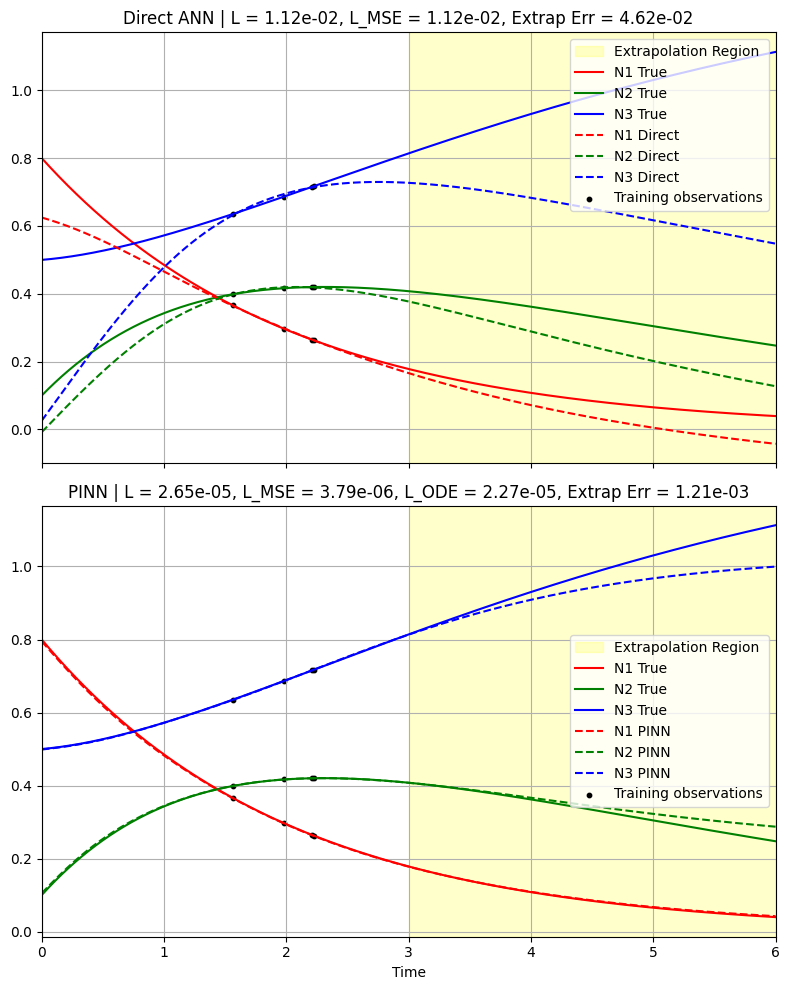

In [10]:
# Plot
fig, axs = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

for ax in axs:
    ax.axvspan(t_end, t_end+prediction_time, color='yellow', alpha=0.2, label='Extrapolation Region')

# Top: Direct ANN
axs[0].plot(t_total, N1_true_total, 'r', label='N1 True')
axs[0].plot(t_total, N2_true_total, 'g', label='N2 True')
axs[0].plot(t_total, N3_true_total, 'b', label='N3 True')
axs[0].plot(t_total, pred_direct_total[:, 0], 'r--', label='N1 Direct')
axs[0].plot(t_total, pred_direct_total[:, 1], 'g--', label='N2 Direct')
axs[0].plot(t_total, pred_direct_total[:, 2], 'b--', label='N3 Direct')
axs[0].scatter(t[indices], N1[indices], c='k', s=10)
axs[0].scatter(t[indices], N2[indices], c='k', s=10)
axs[0].scatter(t[indices], N3[indices], c='k', s=10, label='Training observations')
axs[0].set_xlim([t_start, t_end + prediction_time])
axs[0].set_title(f"Direct ANN | L = {L_direct_total:.2e}, L_MSE = {L_direct_mse:.2e}, Extrap Err = {error_direct:.2e}")
axs[0].legend()
axs[0].grid(True)

# Bottom: PINN
axs[1].plot(t_total, N1_true_total, 'r', label='N1 True')
axs[1].plot(t_total, N2_true_total, 'g', label='N2 True')
axs[1].plot(t_total, N3_true_total, 'b', label='N3 True')
axs[1].plot(t_total, pred_pinn_total[:, 0], 'r--', label='N1 PINN')
axs[1].plot(t_total, pred_pinn_total[:, 1], 'g--', label='N2 PINN')
axs[1].plot(t_total, pred_pinn_total[:, 2], 'b--', label='N3 PINN')
axs[1].scatter(t[indices], N1[indices], c='k', s=10)
axs[1].scatter(t[indices], N2[indices], c='k', s=10)
axs[1].scatter(t[indices], N3[indices], c='k', s=10, label='Training observations')
axs[1].set_xlim([t_start, t_end + prediction_time])
axs[1].set_title(f"PINN | L = {L_pinn_total:.2e}, L_MSE = {L_pinn_mse:.2e}, L_ODE = {L_pinn_ode:.2e}, Extrap Err = {error_pinn:.2e}")
axs[1].legend()
axs[1].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.savefig('Radioactive-decay_PINN.png', dpi=300)
plt.show()


## Interpretation of the quantitative validation

The physics interpretation is the central point of this example. The direct ANN asks: *Which smooth curves fit the sparse observations?* The PINN asks a more restrictive question: *Which smooth curves fit the sparse observations and are consistent with the decay-chain equations?* This distinction matters because four training observations do not uniquely determine the three population curves. Many interpolating functions can pass through those observations, but only a much smaller class of functions also satisfies the coupled ODE system. In this sense, the physics loss acts as an inductive bias: it restricts the learned solution to physically plausible behavior and can improve extrapolation when the governing equations are correct.

The notebook therefore supplements the visual comparison with quantitative validation. Both models are evaluated on dense time grids against the known reference solution. The interpolation error measures agreement inside the observed time interval, whereas the extrapolation error measures how well the learned dynamics continue beyond the training interval. The ODE residual is then evaluated on an unseen validation grid. A low residual indicates that a model satisfies the decay equations, rather than merely passing through the observed data points. Finally, the notebook checks physical consistency: the isotope populations should remain non-negative, and the conserved total population $N_1+N_2+N_3$ should stay close to its initial value. These diagnostics connect model quality directly to physics, because a model can have a small data error while still being physically implausible if it violates the ODEs or conservation of total population.

The comparison plot shows that the direct ANN can fit the sparse observations, but it is less constrained between and beyond them. The PINN is guided by the ODE residual and therefore has an additional reason to follow the reference dynamics in the extrapolation region. This illustrates how data-driven modeling can complement, but not replace, physics-driven modeling. The ANN provides a flexible function approximator; the ODEs provide structure that helps distinguish physically meaningful solutions from arbitrary interpolating curves.

The example also highlights important limitations. A PINN is not automatically superior in every setting. Its performance depends on the correctness of the governing equations, the weighting between data and physics losses, the choice and density of collocation points, and the optimization procedure. Training may also require more computational effort than a direct ANN because derivatives and residuals must be evaluated. In a classroom setting, these limitations are useful: they invite students to discuss how physics-based assumptions, data quality, and numerical optimization interact.
